# BEoRN: Exploring THESAN N-body Data

This notebook is a **hands-on walkthrough** of the raw THESAN-DARK data that BEoRN consumes.  It is designed to be read **before** the full post-processing tutorial (`thesan_merger_tree_postprocessing.ipynb`) to build intuition about the underlying data.

**What we cover:**
1. Read a DM particle snapshot and map it onto a density grid
2. Load the FoF halo catalog and compare the halo mass function (HMF) to an analytical model
3. Read the raw LHaloTree merger tree files and build the simplified BEoRN cache (or load it if it already exists)
4. Visualise main-progenitor branches for a handful of halos
5. Fit the mass-accretion parameter α for each halo and inspect its distribution

**Data used:** [THESAN-DARK 2](https://thesan-project.com) — 95.5 cMpc/h box, 1050³ DM particles, Planck 2015 cosmology, LHaloTree merger trees.

**Prerequisites:** The THESAN data must be available locally (see `FILE_ROOT` below).  The cache extraction step runs once and stores results on disk so subsequent runs are fast.

In [1]:
import os
import numpy as np
from tqdm import tqdm
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import beorn
from beorn.load_input_data.alpha_fitting import vectorized_alpha_fit
from beorn.particle_mapping import map_particles_to_mesh

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 13, 'axes.labelsize': 13,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'legend.fontsize': 11, 'axes.titlesize': 13,
})

INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────
# FILE_ROOT: root of the THESAN-DARK data tree.  Expected layout:
#   FILE_ROOT/output/groups_*/          ← FoF group catalogs
#   FILE_ROOT/output/snapdir_*/         ← DM particle snapshots
#   FILE_ROOT/postprocessing/offsets/   ← subhalo offset files
#   FILE_ROOT/postprocessing/trees/LHaloTree/  ← raw LHaloTree HDF5 files
FILE_ROOT  = Path(os.environ.get("PROJECT", "input")) / "Thesan-Dark-2"
CACHE_ROOT = Path("cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_ROOT / "tree_cache.hdf5"

# ── Snapshot to inspect ────────────────────────────────────────────────────
# Snap 49 ≈ z=7.4 in THESAN-DARK 2; adjust if your download differs.
SNAP_IDX = 49

# ── Resolution flag ────────────────────────────────────────────────────────
IS_HIGH_RES = False  # True for THESAN-DARK 1 (2100³ particles)
PARTICLE_COUNT = 2100**3 if IS_HIGH_RES else 1050**3

## 1. Read a DM snapshot and build the density grid

THESAN stores each snapshot as a set of HDF5 files under `snapdir_NNN/`.  Dark-matter particles live in `PartType1` and their positions are in units of **kpc/h** (comoving).  We convert to **Mpc/h** and use `map_particles_to_mesh` (BEoRN's particle-mesh mapping function) to paint them onto a regular 3-D grid using the CIC scheme.

`map_particles_to_mesh` supports multiple backends — `'numpy'` (default, no extra dependencies), `'numba'`, `'pylians'`, `'torch'`, and `'jax'`.  Here we use `backend='numpy'` which works everywhere including Apple Silicon.

The result is the overdensity field
$$
    \delta(\mathbf{x}) = \frac{\rho(\mathbf{x})}{\langle\rho\rangle} - 1,
$$
which BEoRN uses to modulate the 21-cm signal at each grid cell.

In [3]:
snap_dir = FILE_ROOT / "output" / f"snapdir_{SNAP_IDX:03d}"
snap_files = sorted(snap_dir.glob("snap_*.hdf5"))
print(f"Found {len(snap_files)} snapshot chunk(s) in {snap_dir.name}")

# Read Hubble parameter from the header
with h5py.File(snap_files[0], "r") as f:
    snap_redshift = float(f["Header"].attrs["Redshift"])
    thesan_h      = float(f["Header"].attrs["HubbleParam"])
    box_size_kpc  = float(f["Header"].attrs["BoxSize"])     # kpc/h

box_size_mpc = box_size_kpc * 1e-3/thesan_h   # kpc/h → Mpc
print(f"Snapshot redshift  z = {snap_redshift:.3f}")
print(f"Box size           L = {box_size_mpc:.2f} cMpc")
print(f"Hubble parameter   h = {thesan_h}")

Found 18 snapshot chunk(s) in snapdir_049
Snapshot redshift  z = 7.430
Box size           L = 95.50 cMpc
Hubble parameter   h = 0.6774


In [4]:
# Load all particle positions into a pre-allocated array
particle_positions = np.zeros((PARTICLE_COUNT, 3), dtype=np.float32)
ptr = 0
for snap in tqdm(snap_files, desc="Loading snapshots"):
    with h5py.File(snap, "r") as f:
        pos = f["PartType1"]["Coordinates"][:]
        particle_positions[ptr: ptr + pos.shape[0]] = pos
        ptr += pos.shape[0]

particle_positions *= 1e-3 / thesan_h   # kpc/h → Mpc (comoving, h-free)
print(f"Loaded {ptr:,} DM particles")
print(f"Position range: [{particle_positions.min():.2f}, {particle_positions.max():.2f}] cMpc")

Loading snapshots: 100%|██████████| 18/18 [00:13<00:00,  1.34it/s]


Loaded 1,157,625,000 DM particles
Position range: [0.00, 95.50] cMpc


In [5]:
# Paint particles onto a coarser mesh for visualisation
# (use 128³ here; BEoRN painting typically uses parameters.simulation.Ncell)
GRID_SIZE = 128

mesh = np.zeros((GRID_SIZE, GRID_SIZE, GRID_SIZE), dtype=np.float32)
# backend='numpy' works everywhere (no extra dependencies).
# Other options: 'numba' (faster, pip install beorn[numba]),
#                'pylians' (Fortran/OpenMP, pip install beorn[pylians]),
#                'torch' / 'jax' (differentiable, pip install beorn[torch/jax])
map_particles_to_mesh(mesh, box_size_mpc, particle_positions, mass_assignment="CIC", backend="numpy")

# Overdensity  δ = ρ/⟨ρ⟩ − 1
density_grid = mesh / np.mean(mesh, dtype=np.float64) - 1
print(f"Density field:  min={density_grid.min():.2f}  max={density_grid.max():.2f}  mean={density_grid.mean():.4f}")

Density field:  min=-0.82  max=25.51  mean=-0.0000


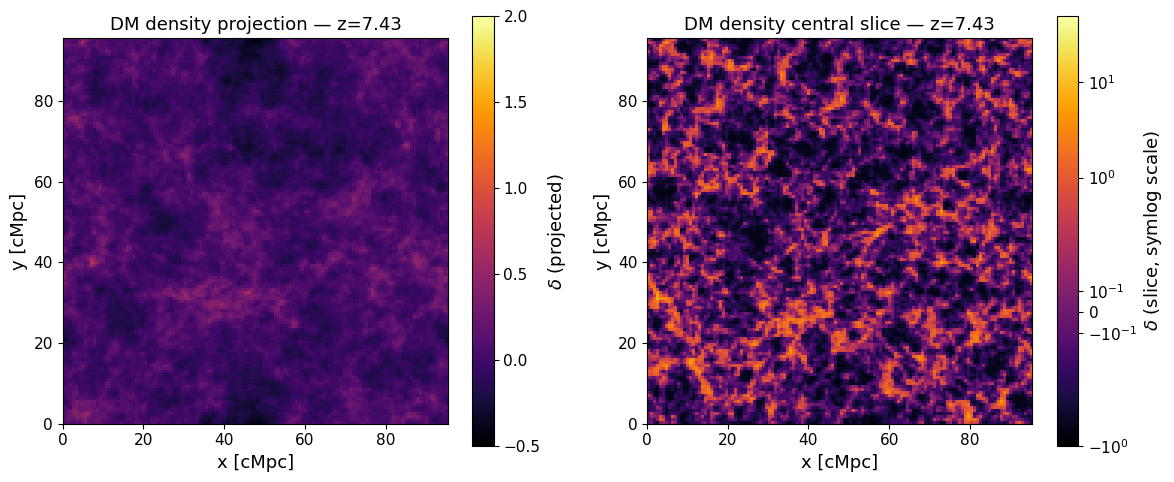

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Projection (mean along z-axis) ────────────────────────────────────────
projection = density_grid.mean(axis=2)
im0 = axes[0].imshow(
    projection, origin="lower",
    extent=[0, box_size_mpc, 0, box_size_mpc],
    cmap="inferno", vmin=-0.5, vmax=2.0,
)
plt.colorbar(im0, ax=axes[0], label=r"$\delta$ (projected)")
axes[0].set_xlabel("x [cMpc]"); axes[0].set_ylabel("y [cMpc]")
axes[0].set_title(f"DM density projection — z={snap_redshift:.2f}")

# ── Central slice ─────────────────────────────────────────────────────────
mid_slice = density_grid[:, :, GRID_SIZE // 2]
im1 = axes[1].imshow(
    mid_slice, origin="lower",
    extent=[0, box_size_mpc, 0, box_size_mpc],
    cmap="inferno",
    norm=mcolors.SymLogNorm(linthresh=0.5, vmin=-1, vmax=50),
)
plt.colorbar(im1, ax=axes[1], label=r"$\delta$ (slice, symlog scale)")
axes[1].set_xlabel("x [cMpc]"); axes[1].set_ylabel("y [cMpc]")
axes[1].set_title(f"DM density central slice — z={snap_redshift:.2f}")

plt.tight_layout()
plt.show()

## 2. Halo catalog and the halo mass function

THESAN stores FoF group catalogs in `output/groups_NNN/`.  For each group we read the total mass (`GroupMass`, in units of $10^{10}\,M_\odot/h$) and use BEoRN's built-in HMF plotter to compare against the Tinker et al. (2008) analytical fit.

The HMF (differential number density of halos per logarithmic mass interval) is defined as
$$
    \frac{dn}{d\ln M} = \frac{N_{\rm halos\ in\ bin}}{V_{\rm box}\,\Delta(\ln M)},
$$
with Poisson error $\sigma = (dn/d\ln M)/\sqrt{N}$.

In [7]:
groups_dir   = FILE_ROOT / "output" / f"groups_{SNAP_IDX:03d}"
offset_dir   = FILE_ROOT / "postprocessing" / "offsets"
offset_file  = next(offset_dir.glob(f"offsets_{SNAP_IDX:03d}.*"))

catalog_files = sorted(groups_dir.rglob("*.hdf5"), key=lambda p: int(p.stem.split(".")[1]))
print(f"Found {len(catalog_files)} catalog chunk(s)")

# Accumulate group masses
all_masses = []
for cf in catalog_files:
    with h5py.File(cf, "r") as f:
        if "GroupMass" not in f["Group"]:
            continue
        gm = f["Group"]["GroupMass"][:]    # 10^10 M☉/h
        all_masses.append(gm)

group_masses_Msol = np.concatenate(all_masses) * 1e10 / thesan_h   # → M☉
print(f"Total groups:     {group_masses_Msol.size:,}")
print(f"Mass range:       {group_masses_Msol.min():.2e} – {group_masses_Msol.max():.2e} M☉")

Found 18 catalog chunk(s)
Total groups:     427,906
Mass range:       9.47e+08 – 6.12e+11 M☉


INFO:beorn.structs.halo_catalog:No alpha values provided, using default value of 0.79 for all halos.


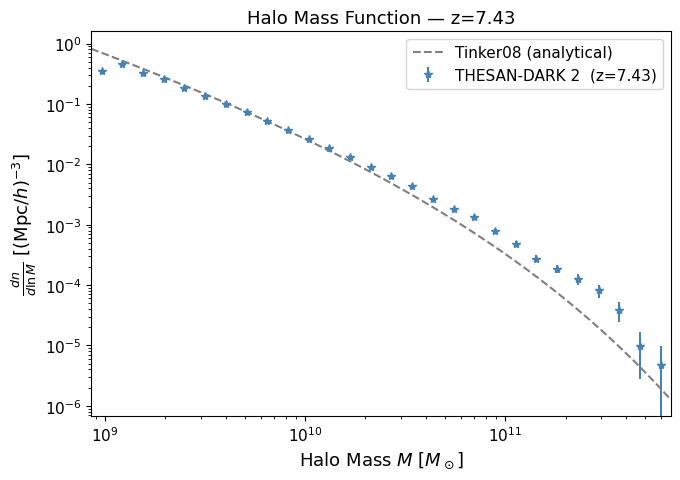

In [8]:
# Build a minimal BEoRN parameter set so we can use the built-in HMF plotter
parameters = beorn.structs.Parameters()
parameters.simulation.Lbox  = box_size_mpc
parameters.simulation.Ncell = GRID_SIZE
parameters.solver.redshifts = np.arange(20, 5.5, -0.5)

# Build a HaloCatalog by hand (positions not needed for the HMF)
from beorn.structs import HaloCatalog
catalog = HaloCatalog(
    positions  = np.zeros((group_masses_Msol.size, 3)),   # placeholder
    masses     = group_masses_Msol,
    parameters = parameters,
    redshift   = snap_redshift,
)

fig, ax = plt.subplots(figsize=(7, 5))
beorn.plotting.plot_halo_mass_function(
    ax, catalog,
    label=f"THESAN-DARK 2  (z={snap_redshift:.2f})",
    color="steelblue",
    analytical=True,
    analytical_model="Tinker08",
)
ax.set_title(f"Halo Mass Function — z={snap_redshift:.2f}")
ax.legend()
plt.tight_layout()
plt.show()

**What to look for:**  The simulation points should follow the Tinker08 curve closely at intermediate masses.  Deviations at the low-mass end indicate the simulation's resolution limit (THESAN-DARK 2 resolves halos down to ~10⁹ M☉).  At the high-mass end, the finite box volume causes a statistical cut-off.

## 3. Reading the merger trees and building the BEoRN cache

THESAN provides merger trees in the **LHaloTree** format (Springel et al. 2005), stored in `postprocessing/trees/LHaloTree/`.  Each HDF5 file contains a collection of independent tree groups (`Tree0`, `Tree1`, …), each holding all halos in one merger tree.

### Key LHaloTree datasets used by BEoRN

| Dataset | Units | Description |
|---|---|---|
| `SnapNum` | — | Snapshot index of this halo |
| `SubhaloNumber` | — | Subhalo index within its snapshot |
| `SubhaloMassType[:,1]` | $10^{10}\,M_\odot/h$ | Dark-matter mass of the subhalo |
| `FirstProgenitor` | tree-local index | Main progenitor (most massive, one snap earlier), or -1 |

BEoRN reads a **simplified, flat HDF5 cache** built from these fields.  The extraction runs once and subsequent runs just load the cache.

> **Note:** Pointer fields like `FirstProgenitor` are *tree-local* (0-based within each tree).  When we concatenate all trees we must add a running offset to convert them to *global* indices.

> **Caveat (Moll 2025, §4 — Master's thesis, ETH Zürich):** The THESAN LHaloTree is built in postprocessing and does not guarantee self-consistent halo properties across snapshots. This produces spurious negative growth rates for a fraction of halos. Following the thesis prescription, halos whose fitted α is outside [0, 5] are considered unreliable and replaced by a **fallback value α = 0.6** (the stabilised mean at n = 10 lookback snapshots, Figure 3 of Moll 2025 — *not a journal paper*).

In [9]:
# ── Peek at the first tree file to understand the data layout ─────────────
tree_dir   = FILE_ROOT / "postprocessing" / "trees" / "LHaloTree"
tree_files = sorted(tree_dir.glob("trees_sf1_*.hdf5"))
print(f"Found {len(tree_files)} LHaloTree file(s)")

with h5py.File(tree_files[0], "r") as f:
    snapshot_redshifts = f["Header"]["Redshifts"][:]
    particle_mass_1e10 = float(f["Header"].attrs["ParticleMass"])  # 10^10 M☉/h
    n_trees_file0      = sum(1 for k in f.keys() if k.startswith("Tree"))
    t0 = f["Tree0"]
    print(f"\nTree0 has {t0['SnapNum'].shape[0]:,} entries")
    print("Fields and shapes:")
    for key in sorted(t0.keys()):
        print(f"  {key:30s} {t0[key].shape}  dtype={t0[key].dtype}")

print(f"\nNumber of snapshots:   {len(snapshot_redshifts)}")
print(f"Redshift range:        z={snapshot_redshifts.max():.2f} → {snapshot_redshifts.min():.2f}")
print(f"DM particle mass:      {particle_mass_1e10 * 1e10 / thesan_h:.3e} M☉")
print(f"Trees in first file:   {n_trees_file0:,}")

Found 18 LHaloTree file(s)

Tree0 has 4,957,604 entries
Fields and shapes:
  Descendant                     (4957604,)  dtype=int32
  FileNr                         (4957604,)  dtype=int32
  FirstHaloInFOFGroup            (4957604,)  dtype=int32
  FirstProgenitor                (4957604,)  dtype=int32
  Group_M_Crit200                (4957604,)  dtype=float32
  Group_M_Mean200                (4957604,)  dtype=float32
  Group_M_TopHat200              (4957604,)  dtype=float32
  Group_R_Crit200                (4957604,)  dtype=float32
  NextHaloInFOFGroup             (4957604,)  dtype=int32
  NextProgenitor                 (4957604,)  dtype=int32
  SnapNum                        (4957604,)  dtype=int32
  SubhaloGrNr                    (4957604,)  dtype=int32
  SubhaloIDMostBound             (4957604,)  dtype=uint64
  SubhaloLen                     (4957604,)  dtype=int32
  SubhaloLenType                 (4957604, 6)  dtype=int32
  SubhaloMassType                (4957604, 6)  dtype=float3

In [10]:
if CACHE_FILE.exists():
    logger.info(f"Tree cache already exists: {CACHE_FILE} — skipping extraction.")
else:
    logger.info("Building tree cache (runs once, result cached to disk)…")

    # Detect available fields once on the first tree
    with h5py.File(tree_files[0], "r") as _f:
        _t      = _f["Tree0"]
        _fields = set(_t.keys())

        _mass_field = "LenType" if "LenType" in _fields else "SubhaloMassType"
        logger.info(f"Mass field: {_mass_field}")

        # Identify the pointer to the first (central) halo in the FoF group.
        # Different THESAN releases use different capitalisations.
        _fof_field = next(
            (name for name in ("FirstHaloInFOFgroup", "FirstHaloInFOFGroup",
                               "FirstHaloInFoFGroup", "FOFHalo")
             if name in _fields),
            None,
        )
        if _fof_field is None:
            raise KeyError(
                f"Cannot find a FoF-first-halo pointer in {list(_fields)}. "
                "Please check the field names printed by cell-s3-inspect-tree."
            )
        logger.info(f"FoF-central field: {_fof_field}")

    all_halo_ids, all_snap_nums, all_masses, all_main_prog, all_is_central = [], [], [], [], []
    global_offset = 0

    for tree_file in tree_files:
        with h5py.File(tree_file, "r") as f:
            tree_keys   = sorted(k for k in f.keys() if k.startswith("Tree"))
            file_offset = 0

            for tk in tree_keys:
                tree    = f[tk]
                n_local = tree["SnapNum"].shape[0]

                snap_num      = tree["SnapNum"][:].astype(np.int32)
                subhalo_index = tree["SubhaloNumber"][:].astype(np.int64)
                first_prog    = tree["FirstProgenitor"][:].astype(np.int64)

                if _mass_field == "LenType":
                    mass = tree["LenType"][:, 1].astype(np.float32) * particle_mass_1e10
                else:
                    mass = tree["SubhaloMassType"][:, 1].astype(np.float32)

                # Central: halo whose tree-local index equals the FoF-first pointer
                fof_first  = tree[_fof_field][:].astype(np.int64)
                local_idx  = np.arange(n_local, dtype=np.int64)
                is_central = (fof_first == local_idx)

                abs_offset = global_offset + file_offset
                main_prog  = np.where(
                    first_prog >= 0,
                    first_prog + abs_offset,
                    np.int64(-1),
                )

                all_halo_ids.append(subhalo_index)
                all_snap_nums.append(snap_num)
                all_masses.append(mass)
                all_main_prog.append(main_prog)
                all_is_central.append(is_central)
                file_offset += n_local

        logger.info(f"  {tree_file.name}: {file_offset:,} entries "
                    f"(cumulative {global_offset + file_offset:,})")
        global_offset += file_offset

    tree_halo_ids        = np.concatenate(all_halo_ids).astype(np.int64)
    tree_snap_nums       = np.concatenate(all_snap_nums).astype(np.int32)
    tree_masses          = np.concatenate(all_masses).astype(np.float32)
    tree_main_progenitor = np.concatenate(all_main_prog).astype(np.int64)
    tree_is_central      = np.concatenate(all_is_central)

    with h5py.File(CACHE_FILE, "w") as f:
        f.attrs["format_version"]              = 2
        f.attrs["generated_by"]                = "beorn"
        f.attrs["simulation_code"]             = "THESAN-DARK-1" if IS_HIGH_RES else "THESAN-DARK-2"
        f.attrs["is_high_res"]                 = IS_HIGH_RES
        f.attrs["hubble_param"]                = thesan_h
        f.attrs["mass_field_used"]             = _mass_field
        f.attrs["fof_field_used"]              = _fof_field
        f.attrs["n_snapshots"]                 = len(snapshot_redshifts)
        f.attrs["n_tree_files"]                = len(tree_files)
        f.attrs["n_total_entries"]             = int(tree_halo_ids.size)
        f.attrs["particle_mass_1e10_Msol_per_h"] = particle_mass_1e10

        f.create_dataset("snapshot_redshifts",   data=np.array(snapshot_redshifts), compression="gzip")
        f.create_dataset("tree_halo_ids",        data=tree_halo_ids,        compression="gzip")
        f.create_dataset("tree_snap_num",        data=tree_snap_nums,       compression="gzip")
        f.create_dataset("tree_mass",            data=tree_masses,          compression="gzip")
        f.create_dataset("tree_main_progenitor", data=tree_main_progenitor, compression="gzip")
        f.create_dataset("tree_is_central",      data=tree_is_central,      compression="gzip")

    logger.info(f"Tree cache saved → {CACHE_FILE}  ({tree_halo_ids.size:,} total entries, "
                f"{tree_is_central.sum():,} centrals)")

INFO:__main__:Tree cache already exists: cache/tree_cache.hdf5 — skipping extraction.


In [11]:
# Load the (possibly just-built) cache
with h5py.File(CACHE_FILE, "r") as f:
    snap_redshifts_all  = f["snapshot_redshifts"][:]
    tree_halo_ids       = f["tree_halo_ids"][:]
    tree_snap_nums      = f["tree_snap_num"][:]
    tree_masses_raw     = f["tree_mass"][:]          # 10^10 M☉/h or counts×mass
    tree_main_prog      = f["tree_main_progenitor"][:]
    tree_is_central     = f["tree_is_central"][:]

tree_masses_Msol = tree_masses_raw * 1e10 / thesan_h   # → M☉

snap_mask_all = tree_snap_nums == SNAP_IDX
print(f"Total entries in cache:   {tree_halo_ids.size:,}")
print(f"Snapshot redshifts:       z={snap_redshifts_all.max():.2f} → {snap_redshifts_all.min():.2f}")
print(f"Entries at snap {SNAP_IDX:3d}:      {snap_mask_all.sum():,}  (z={snap_redshifts_all[SNAP_IDX]:.3f})")
print(f"  of which centrals:      {(snap_mask_all & tree_is_central).sum():,}")

Total entries in cache:   119,607,706
Snapshot redshifts:       z=20.01 → 0.00
Entries at snap  49:      423,981  (z=7.430)
  of which centrals:      392,954


In [12]:
# ── Diagnose tree_halo_ids to understand the central/satellite convention ──
snap_mask_all = tree_snap_nums == SNAP_IDX
ids_at_snap   = tree_halo_ids[snap_mask_all]

print(f"Entries at snap {SNAP_IDX}: {ids_at_snap.size:,}")
print(f"tree_halo_ids (SubhaloNumber) range: min={ids_at_snap.min()}, max={ids_at_snap.max()}")
print(f"Unique values (first 20): {sorted(set(ids_at_snap.tolist()))[:20]}")
print(f"Count with id == 0: {(ids_at_snap == 0).sum():,}")
print(f"Count with id == 1: {(ids_at_snap == 1).sum():,}")

Entries at snap 49: 423,981
tree_halo_ids (SubhaloNumber) range: min=0, max=451283
Unique values (first 20): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Count with id == 0: 1
Count with id == 1: 1


## 4. Visualising merger trees — main progenitor branches

Each halo's **main progenitor branch** traces the most massive predecessor in every preceding snapshot.  BEoRN walks this branch to assemble a mass history array and then fits the exponential growth parameter α (next section).

Here we do the same walk manually for a small sample of halos so we can plot their histories.

In [13]:
# ── Parameters ────────────────────────────────────────────────────────────
N_LOOKBACK   = 10      # snapshots used for alpha fitting (also compared at 5 and 20 below)
Z_MAX        = 12.0    # maximum redshift shown in all history plots
MASS_TARGET  = 1e9     # M☉ — central mass of the selection window

# Filter to central subhalos only (FirstHaloInFOFgroup == self in the tree).
# Satellites are actively stripped → decreasing mass histories, negative alpha.
snap_mask    = (tree_snap_nums == SNAP_IDX) & tree_is_central
snap_indices = np.where(snap_mask)[0]
snap_masses  = tree_masses_Msol[snap_mask]

# Select halos in a 1-dex window around MASS_TARGET, limit to 20 examples
mass_window = (snap_masses > MASS_TARGET * 0.3) & (snap_masses < MASS_TARGET * 3.0)
selected    = snap_indices[mass_window][:20]
print(f"Walking {len(selected)} example central halos back to z={Z_MAX}…")

# Walk each main progenitor branch all the way back to Z_MAX.
# histories_full stores the complete track; histories stores only the N_LOOKBACK
# window used for fitting (same halo, truncated).
histories_full = []   # (zs_full, ms_full) — for display up to Z_MAX
histories      = []   # (zs_fit,  ms_fit)  — N_LOOKBACK window for alpha fitting

for start_idx in selected:
    zs, ms = [], []
    idx = start_idx
    while idx >= 0:
        sn = tree_snap_nums[idx]
        z  = snap_redshifts_all[sn]
        if z > Z_MAX:
            break
        zs.append(z)
        ms.append(tree_masses_Msol[idx])
        idx = int(tree_main_prog[idx])
    if len(zs) > 1:
        histories_full.append((np.array(zs), np.array(ms)))
        # Truncate to N_LOOKBACK steps for fitting
        histories.append((np.array(zs[:N_LOOKBACK + 1]), np.array(ms[:N_LOOKBACK + 1])))

print(f"Successfully walked {len(histories_full)} branches (full to z={Z_MAX})")
print(f"Fitting window:  {N_LOOKBACK} lookback snapshots  "
      f"(z={histories[0][0][0]:.2f} → {histories[0][0][-1]:.2f})")

Walking 20 example central halos back to z=12.0…
Successfully walked 19 branches (full to z=12.0)
Fitting window:  10 lookback snapshots  (z=7.43 → 8.38)


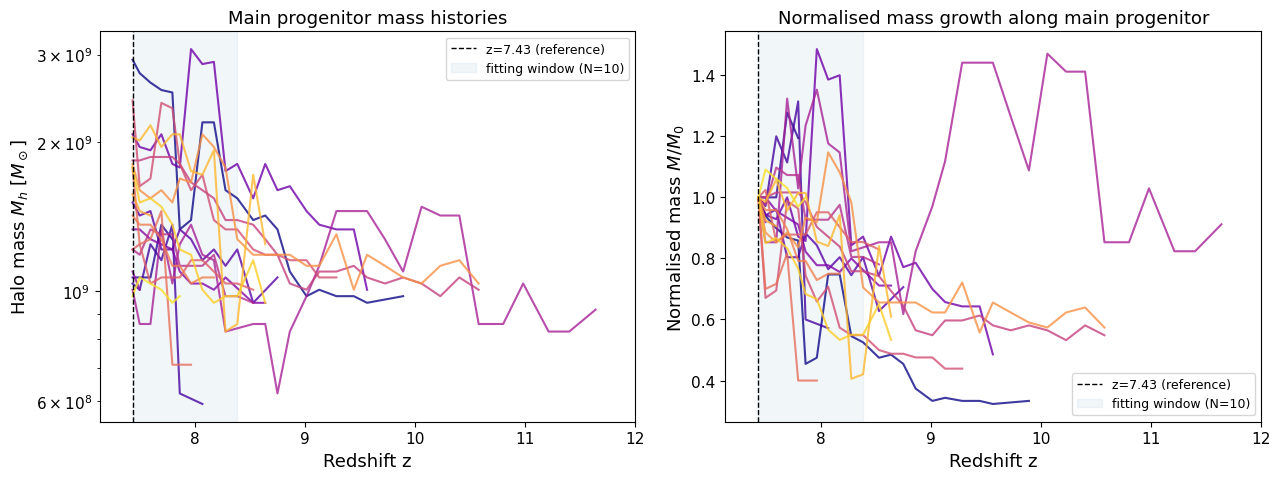

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.cm.plasma

for i, ((zs_full, ms_full), (zs_fit, _)) in enumerate(zip(histories_full, histories)):
    color = cmap(i / len(histories_full))
    axes[0].plot(zs_full, ms_full, color=color, alpha=0.8, lw=1.5)
    axes[1].plot(zs_full, ms_full / ms_full[0], color=color, alpha=0.8, lw=1.5)

z_ref  = snap_redshifts_all[SNAP_IDX]
z_fit_end = histories[0][0][-1]   # oldest redshift in fitting window

for ax in axes:
    ax.axvline(z_ref,     ls="--", color="k",    lw=1,   label=rf"z={z_ref:.2f} (reference)")
    ax.axvspan(z_ref, z_fit_end, alpha=0.07, color="steelblue", label=f"fitting window (N={N_LOOKBACK})")
    ax.set_xlim(z_ref - 0.3, Z_MAX)
    # axes[n].invert_xaxis()  # uncomment to show redshift decreasing left→right
    ax.set_xlabel("Redshift z")

axes[0].set_yscale("log")
axes[0].set_ylabel(r"Halo mass $M_h$ [$M_\odot$]")
axes[0].set_title("Main progenitor mass histories")
axes[0].legend(fontsize=9)

axes[1].set_ylabel(r"Normalised mass $M/M_0$")
axes[1].set_title("Normalised mass growth along main progenitor")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Alpha fitting — individual mass accretion rates

BEoRN parametrises halo growth by a single exponent α in the exponential model
$$
    M_h(z) = M_h(z_0)\,\exp\!\bigl[\alpha\,(z_0 - z)\bigr].
$$
The parameter α is the **specific mass accretion rate** $\alpha = -\dot M_h / M_h$.  In the original BEoRN implementation, α was fixed at 0.79 for all halos (Dekel et al. 2013).  The improved version (Moll 2025) fits α individually from the merger tree.

The fitting is a **log-space linear regression**: writing $y_i = \ln M_0 - \ln M(z_i)$ and $\Delta z_i = z_0 - z_i$ (both positive for lookback), the least-squares estimate is
$$
    \hat\alpha = \frac{\sum_i y_i\,\Delta z_i}{\sum_i (\Delta z_i)^2}.
$$
BEoRN's `vectorized_alpha_fit` implements this in a single NumPy expression across all halos simultaneously.

In [15]:
# Assemble the (n_halos, N_LOOKBACK+1) mass history matrix required by vectorized_alpha_fit.
# Filter to central subhalos only.
snap_mask_target  = (tree_snap_nums == SNAP_IDX) & tree_is_central
all_snap_indices  = np.where(snap_mask_target)[0]
all_snap_masses_0 = tree_masses_Msol[snap_mask_target]

# Keep only halos with a positive current mass
valid = all_snap_masses_0 > 0
all_snap_indices  = all_snap_indices[valid]
all_snap_masses_0 = all_snap_masses_0[valid]

n_halos = len(all_snap_indices)
n_steps = N_LOOKBACK + 1
mass_matrix = np.ones((n_halos, n_steps), dtype=np.float64)
mass_matrix[:, 0] = all_snap_masses_0

# Walk each halo's branch and fill in the mass history.
# Guard against -1 pointers wrapping to the last array element.
prev_ptr = all_snap_indices.copy().astype(np.int64)
for col in range(1, n_steps):
    next_ptr = np.where(
        prev_ptr >= 0,
        tree_main_prog[np.clip(prev_ptr, 0, len(tree_main_prog) - 1)],
        np.int64(-1),
    )
    prog_masses = np.where(
        next_ptr >= 0,
        tree_masses_Msol[np.clip(next_ptr, 0, len(tree_masses_Msol) - 1)],
        mass_matrix[:, col - 1],   # no progenitor → hold mass constant
    )
    mass_matrix[:, col] = prog_masses
    prev_ptr = next_ptr

# Redshifts for the lookback window (current → past, ascending order required)
lookback_snaps     = np.arange(SNAP_IDX, SNAP_IDX - n_steps, -1).clip(0, len(snap_redshifts_all) - 1)
lookback_redshifts = snap_redshifts_all[lookback_snaps]

print(f"Assembled mass history matrix: {mass_matrix.shape} (n_halos × n_steps)")
print(f"Lookback redshifts:  z={lookback_redshifts[0]:.2f} → {lookback_redshifts[-1]:.2f}")

Assembled mass history matrix: (392954, 11) (n_halos × n_steps)
Lookback redshifts:  z=7.43 → 8.38


In [16]:
# Ensure all masses are strictly positive before fitting
mass_matrix = np.clip(mass_matrix, 1e-30, None)

alphas_raw = vectorized_alpha_fit(lookback_redshifts, mass_matrix)

# Apply the thesis prescription (Moll 2025 Master's thesis, §4.3):
#   - The THESAN LHaloTree does not guarantee self-consistent halo properties
#     across snapshots, producing spurious negative growth rates.
#   - Halos with α outside [0, 5] are considered unreliable (erratic/incomplete
#     trees) and replaced by a fallback value tuned to the mean accretion rate.
#   - Upper limit α = 5 affects < 1% of halos; fallback ≈ 0.6 matches the
#     stabilised mean at n = 10 lookback snapshots (Moll 2025 Master's thesis, Figure 3).
ALPHA_MIN     = 0.0
ALPHA_MAX     = 5.0
ALPHA_FALLBACK = 0.6

reliable      = np.isfinite(alphas_raw) & (alphas_raw >= ALPHA_MIN) & (alphas_raw <= ALPHA_MAX)
alphas_fitted = np.where(reliable, alphas_raw, ALPHA_FALLBACK)

print(f"Fitted {alphas_fitted.size:,} alpha values")
print(f"  Reliable (in [{ALPHA_MIN}, {ALPHA_MAX}]): {reliable.sum():,}  ({100*reliable.mean():.1f}%)")
print(f"  Fallback applied:                {(~reliable).sum():,}  ({100*(~reliable).mean():.1f}%)")
print(f"  mean   α = {alphas_fitted.mean():.3f}")
print(f"  median α = {np.median(alphas_fitted):.3f}")
print(f"  std    α = {alphas_fitted.std():.3f}")

Fitted 392,954 alpha values
  Reliable (in [0.0, 5.0]): 354,284  (90.2%)
  Fallback applied:                38,670  (9.8%)
  mean   α = 0.388
  median α = 0.333
  std    α = 0.311


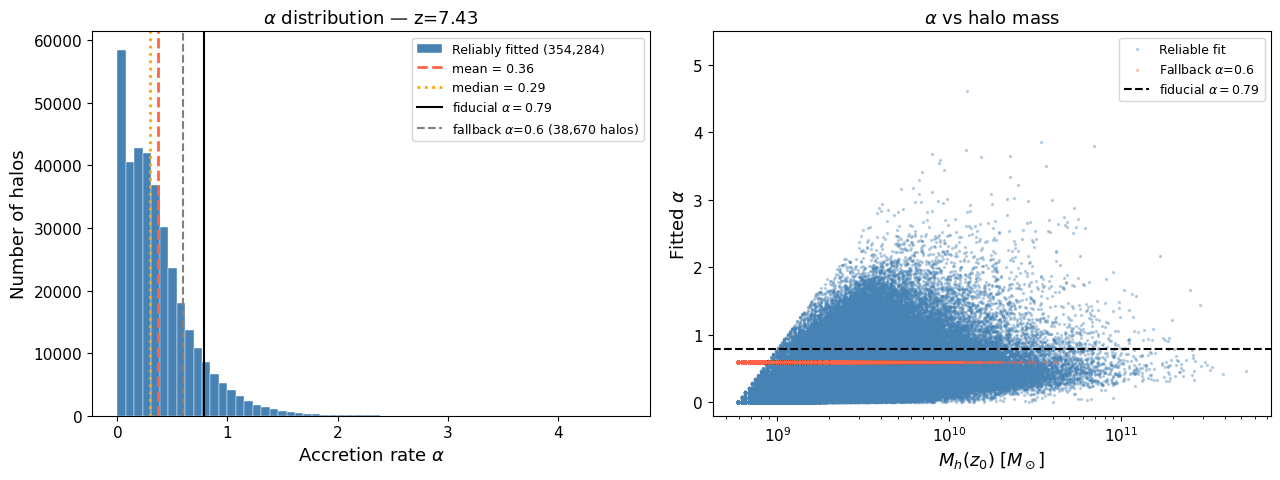

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: α distribution ──────────────────────────────────────────────────
alpha_reliable = alphas_raw[np.isfinite(alphas_raw) & (alphas_raw >= ALPHA_MIN) & (alphas_raw <= ALPHA_MAX)]
alpha_fallback_count = (~reliable).sum()

axes[0].hist(alpha_reliable, bins=60, color="steelblue", edgecolor="white", linewidth=0.3,
             label=f"Reliably fitted ({len(alpha_reliable):,})")
axes[0].axvline(alpha_reliable.mean(),     color="tomato",  lw=2, ls="--",
                label=rf"mean = {alpha_reliable.mean():.2f}")
axes[0].axvline(np.median(alpha_reliable), color="orange",  lw=2, ls=":",
                label=rf"median = {np.median(alpha_reliable):.2f}")
axes[0].axvline(0.79,         color="k",    lw=1.5, ls="-",  label=r"fiducial $\alpha=0.79$")
axes[0].axvline(ALPHA_FALLBACK, color="grey", lw=1.5, ls="--",
                label=rf"fallback $\alpha$={ALPHA_FALLBACK} ({alpha_fallback_count:,} halos)")
axes[0].set_xlabel(r"Accretion rate $\alpha$")
axes[0].set_ylabel("Number of halos")
axes[0].set_title(rf"$\alpha$ distribution — z={snap_redshifts_all[SNAP_IDX]:.2f}")
axes[0].legend(fontsize=9)

# ── Right: α vs halo mass scatter ─────────────────────────────────────────
axes[1].scatter(
    all_snap_masses_0[reliable],
    alphas_raw[reliable],
    s=2, alpha=0.3, color="steelblue", label="Reliable fit",
)
axes[1].scatter(
    all_snap_masses_0[~reliable],
    np.full((~reliable).sum(), ALPHA_FALLBACK),
    s=2, alpha=0.3, color="tomato", label=rf"Fallback $\alpha$={ALPHA_FALLBACK}",
)
axes[1].axhline(0.79, color="k", lw=1.5, ls="--", label=r"fiducial $\alpha=0.79$")
axes[1].set_xscale("log")
axes[1].set_ylim(-0.2, 5.5)
axes[1].set_xlabel(r"$M_h(z_0)\;[M_\odot]$")
axes[1].set_ylabel(r"Fitted $\alpha$")
axes[1].set_title(r"$\alpha$ vs halo mass")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

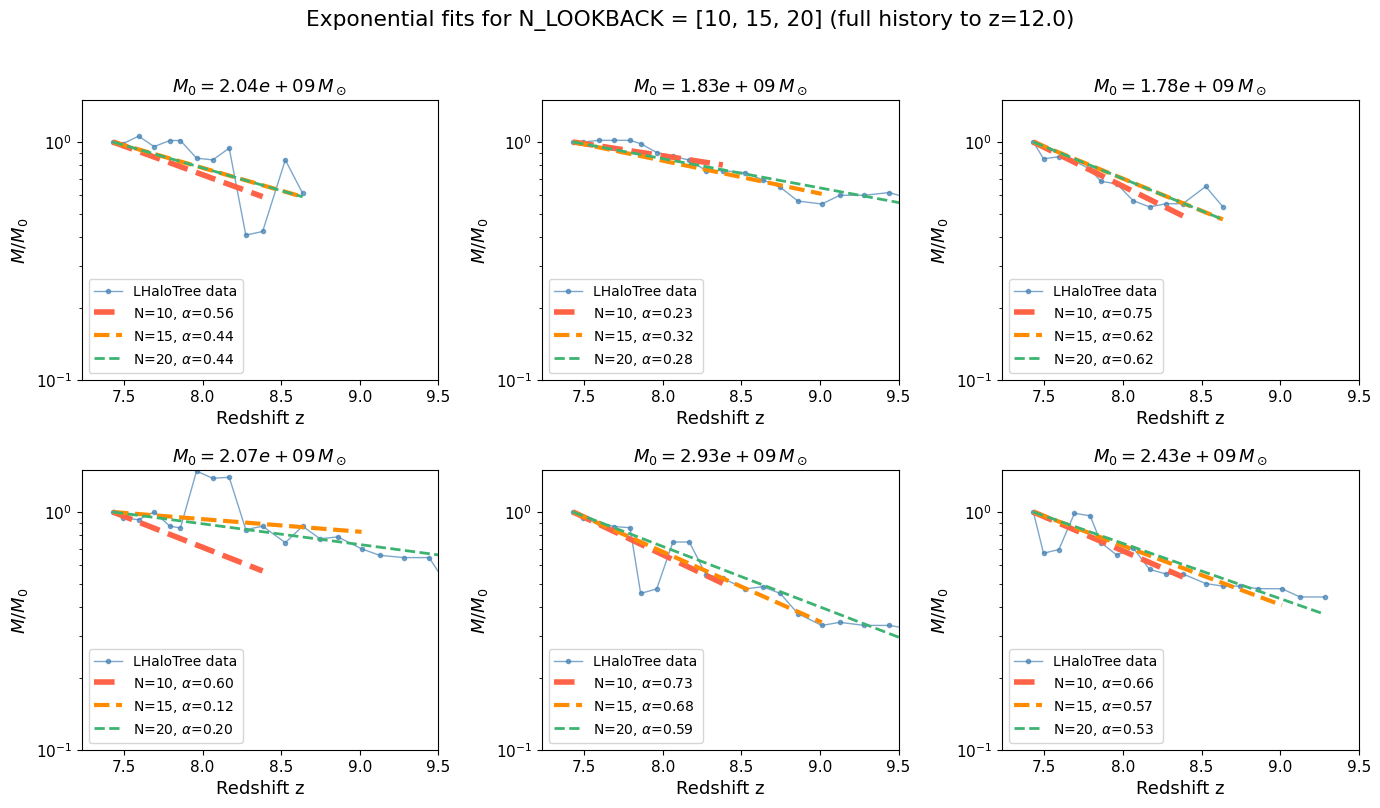

In [18]:
# ── Show 6 example halos: full history to Z_MAX with fits at N=5, 10, 20 ──
rng    = np.random.default_rng(123)
n_show = 6
sample = rng.choice(len(histories_full), size=min(n_show, len(histories_full)), replace=False)

LOOKBACK_COMPARE = [10, 15, 20]
lb_colors        = ["tomato", "darkorange", "mediumseagreen"]
lb_lwidth        = [4, 3, 2]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)
axes = axes.flatten()

for ax_i, hist_i in enumerate(sample):
    zs_full, ms_full = histories_full[hist_i]
    M0 = ms_full[0]
    z0 = zs_full[0]

    # Plot full data track
    axes[ax_i].semilogy(zs_full, ms_full / M0, "o-", ms=3, lw=1,
                        color="steelblue", alpha=0.7, label="LHaloTree data")

    # Overlay exponential fits for each lookback length
    for n_lb, lc, lw in zip(LOOKBACK_COMPARE, lb_colors, lb_lwidth):
        zs_fit = zs_full[:n_lb + 1]
        ms_fit = np.clip(ms_full[:n_lb + 1], 1e-30, None)
        if len(zs_fit) < 2:
            continue
        a_raw = vectorized_alpha_fit(zs_fit, ms_fit[np.newaxis, :])[0]
        if np.isfinite(a_raw) and ALPHA_MIN <= a_raw <= ALPHA_MAX:
            a = a_raw
        else:
            a = ALPHA_FALLBACK

        # Draw fit only over its fitting window
        z_fit_end = zs_fit[-1]
        z_model   = np.linspace(z0, z_fit_end, 80)
        M_model   = M0 * np.exp(a * (z0 - z_model))
        axes[ax_i].semilogy(z_model, M_model / M0, "--", lw=lw, color=lc,
                            label=rf"N={n_lb}, $\alpha$={a:.2f}")

    axes[ax_i].set_ylim(1e-1, 1.5)
    axes[ax_i].set_xlim(z0 - 0.2, 9.5) #Z_MAX
    # axes[ax_i].invert_xaxis()  # uncomment to show redshift decreasing left→right
    axes[ax_i].set_xlabel("Redshift z")
    axes[ax_i].set_ylabel(r"$M/M_0$")
    axes[ax_i].set_title(rf"$M_0 = {M0:.2e}\,M_\odot$")
    axes[ax_i].legend(loc='lower left', fontsize=10)

plt.suptitle(rf"Exponential fits for N_LOOKBACK = {LOOKBACK_COMPARE} (full history to z={Z_MAX})",
             y=1.01)
plt.tight_layout()
plt.show()

## Summary

In this notebook we:

1. **Mapped a DM snapshot onto a density grid** using the CIC mass-assignment scheme and visualised the large-scale structure as both a projected map and a central slice.
2. **Loaded the FoF halo catalog** and compared the simulation HMF against the Tinker et al. (2008) model — the simulation follows the analytical prediction well down to its resolution limit (~10⁹ M☉).
3. **Built (or loaded) the simplified BEoRN tree cache** from the raw LHaloTree HDF5 files.  The cache stores four parallel arrays (`tree_halo_ids`, `tree_snap_num`, `tree_mass`, `tree_main_progenitor`) in a flat HDF5 file that the BEoRN merger tree loader reads at runtime.
4. **Visualised main progenitor branches** for a sample of halos, showing the diversity of growth histories.
5. **Fitted α individually** for each halo using `vectorized_alpha_fit`, and showed that the mean α < 0.79 (the old fiducial value) — motivating the per-halo treatment described in Moll (2025).

**Next steps:** Proceed to [`thesan_merger_tree_postprocessing.ipynb`](thesan_merger_tree_postprocessing.ipynb) to use these ingredients to paint full 3-D 21-cm maps with individual halo accretion rates.